# **Version 1 - Ensemble Model**

### **Section 1 - Import Libraries**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import random
import sys
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import models

### **Section 2 - Device Configuration**

In [2]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using device: cpu
Using Apple GPU (MPS)


### **Section 3 - File path and Pipeline Configuration**

In [3]:
sys.path.append(os.path.abspath(".."))

#This is the path where it import files located in parent directory

In [4]:
from src.data_loader import *
from src.transforms import *
from src.models import *
from src.train import *
from src.evaluate import *
print("Files Imported Successfully")

#These commands are for conncting this file with other files in the pipeline.

Train Shape: (9580, 48, 48, 3)
Validation Shape: (2395, 48, 48, 3)
Test Shape: (6065, 48, 48, 3)
Unique Labels: [0 1 2]
Converted Train Labels: [0 1]
Converted Validation Labels: [0 1]
Converted Test Labels: [0 1]
Train Label Distribution:
[3200 6380]
Validation Label Distribution:
[ 875 1520]
Test Label Distribution:
[2245 3820]
Tomato Images: 20955
Maize Images: 400
Tomato Labels: [0 1]
Maize Labels: [0 1]
Tomato Train: 14668
Tomato Validation: 3143
Tomato Test: 3144
Maize Train: 280
Maize Validation: 60
Maize Test: 60
Using Apple GPU (MPS)
All Baseline Models Created Successfully
All Improved Models Created Successfully
Feature Extractors Created
Fusion Model Created Successfully
Domain Generalisation Model Created Successfully
Files Imported Successfully


### **Section 4 - Sample Images from Datsets** 

#### Tomato Dataset

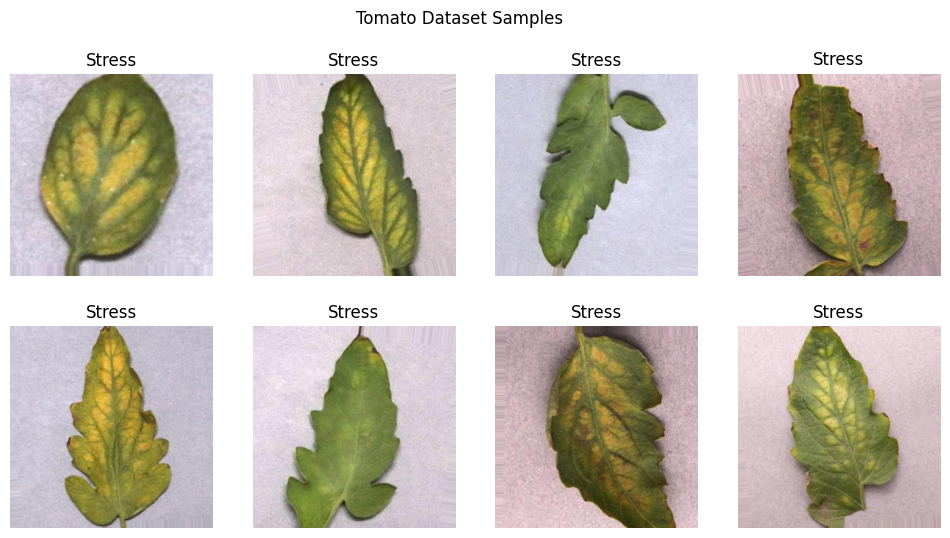

In [5]:
label_names = {
    0: "Non-stress",
    1: "Stress"
}

# Random sample indices
random_indices = random.sample(range(len(tomato_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(tomato_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = tomato_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Tomato Dataset Samples")
plt.show()

#### Maize Dataset

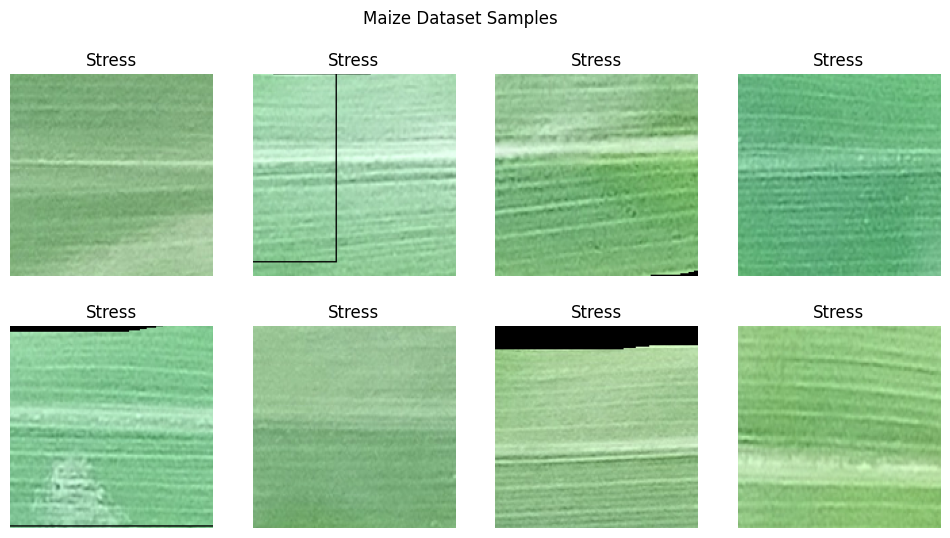

In [6]:
random_indices = random.sample(range(len(maize_images)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    image = cv2.imread(maize_images[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label = maize_labels[idx]

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(label_names[label])   # class name
    plt.axis("off")

plt.suptitle("Maize Dataset Samples")
plt.show()

#### Maize-2 Dataset

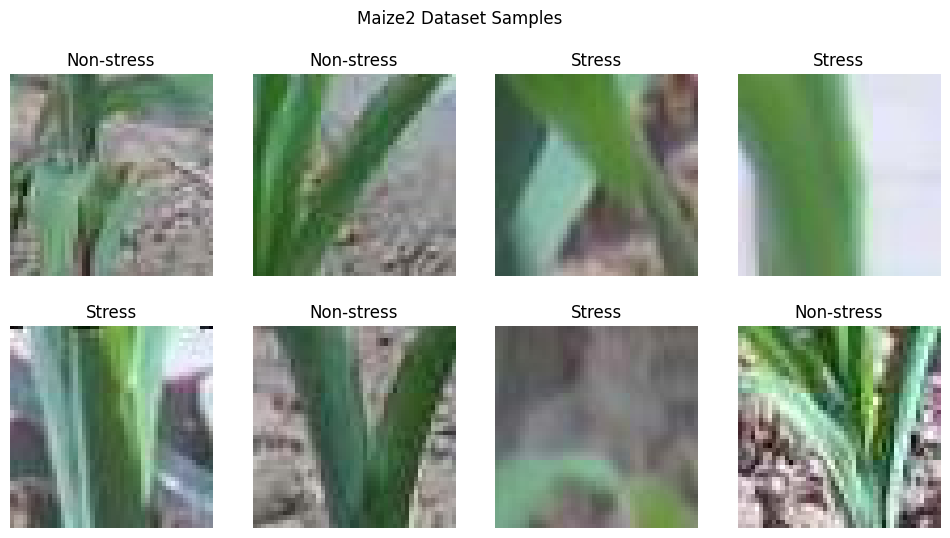

In [7]:
random_indices = random.sample(range(len(train_maize2_data)), 8)

plt.figure(figsize=(12,6))

for i, idx in enumerate(random_indices):

    # Directly get image array
    image = train_maize2_data[idx]

    # Get label
    label = train_maize2_labels[idx]

    plt.subplot(2,4,i+1)

    # Display image
    plt.imshow(image.astype("uint8"))

    plt.title(label_names[label])

    plt.axis("off")

plt.suptitle("Maize2 Dataset Samples")

plt.show()

### **Section 5 - Create Datasets and Dataloaders**

In [8]:
# Datasets

#Train Datasets
tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, transform)

maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, transform)

maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, transform)

# Validation Datasets
tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, transform)

maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, transform)

maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, transform)

# Test Datasets
tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, transform)

maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, transform)

maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, transform)


#Dataloaders

batch_size = 32

#Tomato Dataloaders
tomato_train_loader = DataLoader(
    tomato_train_dataset, batch_size=batch_size, shuffle=True)
tomato_val_loader = DataLoader(
    tomato_val_dataset, batch_size=batch_size, shuffle=False)
tomato_test_loader = DataLoader(
    tomato_test_dataset, batch_size=batch_size, shuffle=False)

#Maize Dataloaders
maize_train_loader = DataLoader(
    maize_train_dataset, batch_size=batch_size, shuffle=True)
maize_val_loader = DataLoader(
    maize_val_dataset, batch_size=batch_size, shuffle=False)
maize_test_loader = DataLoader(
    maize_test_dataset, batch_size=batch_size, shuffle=False)

#Maize2 Dataloaders
maize2_train_loader = DataLoader(
    maize2_train_dataset, batch_size=batch_size, shuffle=True)
maize2_val_loader = DataLoader(
    maize2_val_dataset, batch_size=batch_size, shuffle=False)
maize2_test_loader = DataLoader(
    maize2_test_dataset, batch_size=batch_size, shuffle=False)

### **Section 6 - Loss Function and Optimizer**

In [9]:
criterion = nn.CrossEntropyLoss()

# Tomato Optimizer
tomato_optimizer = torch.optim.Adam(
    tomato_model.parameters(),
    lr=0.001
)

# Maize Optimizer
maize_optimizer = torch.optim.Adam(
    maize_model.parameters(),
    lr=0.001
)

# Maize2 Optimizer
maize2_optimizer = torch.optim.Adam(
    maize2_model.parameters(),
    lr=0.001
)

### **Section 7 - Train Baseline Model**

In [10]:
print("Training Tomato Model")

train_model(
    tomato_model,
    tomato_train_loader,
    tomato_val_loader,
    tomato_optimizer,
    criterion,
    device,
    epochs=5
)

print("Training Maize Model")

train_model(
    maize_model,
    maize_train_loader,
    maize_val_loader,
    maize_optimizer,
    criterion,
    device,
    epochs=5
)

print("Training Maize2 Model")

train_model(
    maize2_model,
    maize2_train_loader,
    maize2_val_loader,
    maize2_optimizer,
    criterion,
    device,
    epochs=5
)

Training Tomato Model
Epoch [1/5]
Train Loss: 0.0288
Train Accuracy: 99.08%
Validation Accuracy: 99.62%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0133
Train Accuracy: 99.55%
Validation Accuracy: 99.65%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0083
Train Accuracy: 99.71%
Validation Accuracy: 98.85%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0099
Train Accuracy: 99.71%
Validation Accuracy: 99.75%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0119
Train Accuracy: 99.65%
Validation Accuracy: 99.87%
----------------------------------------
Training Maize Model
Epoch [1/5]
Train Loss: 0.2562
Train Accuracy: 89.29%
Validation Accuracy: 25.00%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0202
Train Accuracy: 100.00%
Validation Accuracy: 56.67%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0174
Train Accuracy: 99.64%
Validation Accuracy: 91.67%
-------------

([0.14594734559146066,
  0.08984757254365831,
  0.07040882396046072,
  0.05428788539759504,
  0.0496208272218549],
 [94.38413361169103,
  96.5866388308977,
  97.34864300626305,
  98.05845511482255,
  98.13152400835074],
 [93.23590814196243,
  93.23590814196243,
  92.19206680584551,
  93.94572025052192,
  93.40292275574113])

### **Section 8 - Save and Load Models**

In [11]:
# Save models

os.makedirs("saved_models", exist_ok=True)

# Save trained model
torch.save(
    tomato_model.state_dict(),
    "saved_models/tomato_model.pth"
)

torch.save(
    maize_model.state_dict(),
    "saved_models/maize_model.pth"
)

torch.save(
    maize2_model.state_dict(),
    "saved_models/maize2_model.pth"
)


In [12]:
# Load saved models

tomato_model.load_state_dict(
    torch.load(
        "saved_models/tomato_model.pth",
        map_location=device
    )
)

maize_model.load_state_dict(
    torch.load(
        "saved_models/maize_model.pth",
        map_location=device
    )
)

maize2_model.load_state_dict(
    torch.load(
        "saved_models/maize2_model.pth",
        map_location=device
    )
)

# Set models to evaluation mode
tomato_model.eval()

maize_model.eval()

maize2_model.eval()

print("All saved models loaded successfully")

All saved models loaded successfully


### **Section 9 - Test Accuracies of Individual Models**

In [ ]:
# Test individual models on their respective test datasets

print("Tomato Model Performance")

tomato_acc = evaluate_model(
    tomato_model,
    tomato_test_loader,
    device
)

print("Maize Model Performance")

maize_acc = evaluate_model(
    maize_model,
    maize_test_loader,
    device
)

print("Maize2 Model Performance")

maize2_acc = evaluate_model(
    maize2_model,
    maize2_test_loader,
    device
)

Tomato Model Performance
Test Accuracy: 99.84%
Maize Model Performance
Test Accuracy: 100.00%
Maize2 Model Performance
Test Accuracy: 92.81%


### **Section 10 - Ensemble Model**

In [15]:
#Test Ensemble Model

sample_image, sample_label = tomato_test_dataset[0]

prediction = ensemble_predict(
    sample_image,
    tomato_model,
    maize_model,
    maize2_model,
    device
)

print("Actual Label:", sample_label)
print("Predicted Label:", prediction)

Actual Label: 1
Predicted Label: 1


In [16]:
#Merge all test datasets for ensemble evaluation

# Combine all test images
merged_test_data = (
    test_tomato_data +
    test_maize_data +
    list(test_maize2_data)
)

# Combine all test labels

merged_test_labels = (
    list(test_tomato_labels) +
    list(test_maize_labels) +
    list(test_maize2_labels)
)

print("Total Test Images:", len(merged_test_data))
print("Total Test Labels:", len(merged_test_labels))

Total Test Images: 9269
Total Test Labels: 9269


In [17]:
merged_test_dataset = LeafDataset(
    merged_test_data,
    merged_test_labels,
    transform
)

In [21]:
#Checking the ensemble model performance on the merged test dataset

ensemble_acc = evaluate_ensemble(
    merged_test_dataset,
    tomato_model,
    maize_model,
    maize2_model,
    device
)

Ensemble Accuracy: 71.43%


# **Version 2 - Fine-tunned Ensemble Model**

### **Section 11 - Create Improved Datasets and Dataloaders**

In [22]:
#Create Improved Datasets

#Tomato Datasets
improved_tomato_train_dataset = LeafDataset(
    train_tomato_data, train_tomato_labels, improved_transform
)
improved_tomato_val_dataset = LeafDataset(
    val_tomato_data, val_tomato_labels, improved_transform
)
improved_tomato_test_dataset = LeafDataset(
    test_tomato_data, test_tomato_labels, improved_transform
)

#Maize Datasets
improved_maize_train_dataset = LeafDataset(
    train_maize_data, train_maize_labels, improved_transform
)   
improved_maize_val_dataset = LeafDataset(
    val_maize_data, val_maize_labels, improved_transform
)
improved_maize_test_dataset = LeafDataset(
    test_maize_data, test_maize_labels, improved_transform
)

#Maize2 Datasets
improved_maize2_train_dataset = LeafDataset(
    train_maize2_data, train_maize2_labels, improved_transform
)
improved_maize2_val_dataset = LeafDataset(
    val_maize2_data, val_maize2_labels, improved_transform
)
improved_maize2_test_dataset = LeafDataset(
    test_maize2_data, test_maize2_labels, improved_transform
)

In [23]:
#Improved Dataloaders

#Tomato Dataloaders
improved_tomato_train_loader = DataLoader(
    improved_tomato_train_dataset, batch_size=32, shuffle=True
)
improved_tomato_val_loader = DataLoader(
    improved_tomato_val_dataset, batch_size=32, shuffle=False
)
improved_tomato_test_loader = DataLoader(
    improved_tomato_test_dataset, batch_size=32, shuffle=False
)

#Maize Dataloaders
improved_maize_train_loader = DataLoader(
    improved_maize_train_dataset, batch_size=32, shuffle=True
)
improved_maize_val_loader = DataLoader(
    improved_maize_val_dataset, batch_size=32, shuffle=False
)
improved_maize_test_loader = DataLoader(
    improved_maize_test_dataset, batch_size=32, shuffle=False
)

#Maize2 Dataloaders
improved_maize2_train_loader = DataLoader(
    improved_maize2_train_dataset, batch_size=32, shuffle=True
)
improved_maize2_val_loader = DataLoader(
    improved_maize2_val_dataset, batch_size=32, shuffle=False
)
improved_maize2_test_loader = DataLoader(
    improved_maize2_test_dataset, batch_size=32, shuffle=False
)

### **Section 12 - Improved Optimisers**

In [24]:
improved_tomato_optimizer = torch.optim.Adam(
    improved_tomato_model.parameters(),
    lr=0.0001
)

improved_maize_optimizer = torch.optim.Adam(
    improved_maize_model.parameters(),
    lr=0.0001
)

improved_maize2_optimizer = torch.optim.Adam(
    improved_maize2_model.parameters(),
    lr=0.0001
)

### **Section 13 - Train Improved Model**

In [25]:
print("Training Improved Tomato Model")

train_model(
    improved_tomato_model,
    improved_tomato_train_loader,
    improved_tomato_val_loader,
    improved_tomato_optimizer,
    criterion,
    device,
    epochs=15
)


print("Training Improved Maize Model")

train_model(
    improved_maize_model,
    improved_maize_train_loader,
    improved_maize_val_loader,
    improved_maize_optimizer,
    criterion,
    device,
    epochs=15
)


print("Training Improved Maize2 Model")

train_model(
    improved_maize2_model,
    improved_maize2_train_loader,
    improved_maize2_val_loader,
    improved_maize2_optimizer,
    criterion,
    device,
    epochs=15
)

Training Improved Tomato Model
Epoch [1/15]
Train Loss: 0.0522
Train Accuracy: 98.79%
Validation Accuracy: 99.97%
----------------------------------------
Epoch [2/15]
Train Loss: 0.0069
Train Accuracy: 99.80%
Validation Accuracy: 100.00%
----------------------------------------
Epoch [3/15]
Train Loss: 0.0013
Train Accuracy: 99.97%
Validation Accuracy: 99.97%
----------------------------------------
Epoch [4/15]
Train Loss: 0.0037
Train Accuracy: 99.89%
Validation Accuracy: 99.87%
----------------------------------------
Epoch [5/15]
Train Loss: 0.0012
Train Accuracy: 99.98%
Validation Accuracy: 100.00%
----------------------------------------
Epoch [6/15]
Train Loss: 0.0020
Train Accuracy: 99.95%
Validation Accuracy: 99.97%
----------------------------------------
Epoch [7/15]
Train Loss: 0.0005
Train Accuracy: 99.99%
Validation Accuracy: 100.00%
----------------------------------------
Epoch [8/15]
Train Loss: 0.0023
Train Accuracy: 99.92%
Validation Accuracy: 99.97%
---------------

([0.19840209835519393,
  0.1084304720411698,
  0.08915685823187232,
  0.07970575809168319,
  0.06888533071614802,
  0.06151548592373729,
  0.053127854482736436,
  0.045081210325782495,
  0.039430634093781315,
  0.0372351134174581,
  0.0320417703241886,
  0.026283742558055868,
  0.030091310150843733,
  0.023477747187328837,
  0.024335315672748645],
 [92.30688935281837,
  95.77244258872652,
  96.5553235908142,
  96.97286012526096,
  97.44258872651356,
  97.839248434238,
  98.07933194154488,
  98.37160751565762,
  98.46555323590815,
  98.59081419624218,
  98.92484342379959,
  99.03966597077245,
  99.08141962421712,
  99.24843423799582,
  99.12317327766179],
 [91.06471816283924,
  91.77453027139875,
  90.77244258872652,
  92.90187891440502,
  92.90187891440502,
  92.02505219206681,
  91.10647181628393,
  91.52400835073068,
  90.52192066805846,
  93.52818371607516,
  93.36116910229646,
  91.98329853862212,
  90.81419624217119,
  88.18371607515658,
  93.40292275574113])

### **Section 14 - Save and Load Improved Models**

In [26]:
# Save Improved Tomato Model
torch.save(
    improved_tomato_model.state_dict(),
    "saved_models/improved_tomato_model.pth"
)

# Save Improved Maize Model
torch.save(
    improved_maize_model.state_dict(),
    "saved_models/improved_maize_model.pth"
)

# Save Improved Maize2 Model
torch.save(
    improved_maize2_model.state_dict(),
    "saved_models/improved_maize2_model.pth"
)

print("All Improved Models Saved Successfully")

All Improved Models Saved Successfully


In [ ]:
# Load improved models

improved_tomato_model.load_state_dict(
    torch.load(
        "saved_models/improved_tomato_model.pth",
        map_location=device
    )
)

improved_maize_model.load_state_dict(
    torch.load(
        "saved_models/improved_maize_model.pth",
        map_location=device
    )
)

improved_maize2_model.load_state_dict(
    torch.load(
        "saved_models/improved_maize2_model.pth",
        map_location=device
    )
)

# Set evaluation mode
improved_tomato_model.eval()
improved_maize_model.eval()
improved_maize2_model.eval()

print("All Improved Models Loaded Successfully")

All Improved Models Loaded Successfully


### **Section 15 - Test Improved Ensemble Model**

In [28]:
improved_ensemble_acc = evaluate_improved_ensemble(
    merged_test_dataset,
    improved_tomato_model,
    improved_maize_model,
    improved_maize2_model,
    device
)

Improved Ensemble Accuracy: 75.40%
